# Análisis de Datos: Experimento de Eratóstenes

**Fechas de medición:**
- 19 de marzo de 2026 (un día antes del equinoccio de primavera)
- 20 de marzo de 2026 (equinoccio de primavera)

**Autores:** Jean Lucca Buritica Cuervo, Daniel Soto Villada, Camilo Higuita  
**Coordenadas:** $\varphi = 6.2666°\,\text{N}$, $\lambda = -75.5694°\,\text{W}$ (Medellín, Colombia)  

| Parámetro | Conjunto A (20 mar) | Conjunto B (19 mar) |
|:---|:---:|:---:|
| Archivo | `Datos20260320.dat` | `Datos20260319.dat` |
| Longitud del gnomon $H$ (cm) | $102.0 \pm 0.1$ | $112.0 \pm 0.1$ |
| Error en sombra $\sigma_L$ (cm) | $\pm 0.3$ | $\pm 0.4$ |
| Formato de columnas | `HH:MM  sombra` | `sombra  HH:MM:SS` |
| Declinación solar $\delta$ | $\approx 0°$ | $\approx -0.48°$ |

---

In [15]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'lines.linewidth': 2,
    'errorbar.capsize': 4,
})
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 1. Fundamento Teórico

### 1.1 El método de Eratóstenes

Eratóstenes de Cirene (c. 276–195 a.C.) midió la circunferencia de la Tierra comparando los ángulos de sombra del gnomon en dos ciudades diferentes (Siena y Alejandría) al mediodía del solsticio de verano. La clave del método es que, si la Tierra es esférica y los rayos del Sol llegan paralelos, la diferencia de ángulos cenital entre dos puntos sobre el mismo meridiano es igual al ángulo que subtienden en el centro de la Tierra.

En esta reproducción moderna, usamos el ecuador (línea en que el Sol queda en el cénit al mediodía del equinoccio, $\delta = 0$) como punto de referencia, y Medellín ($\varphi = 6.2666°\,\text{N}$) como el sitio de observación.

### 1.2 Ángulo cenital al mediodía solar

La longitud de la sombra $L$ proyectada por un gnomon vertical de altura $H$ permite calcular el ángulo cenital $\theta_z$ mediante:

$$\theta_z = \arctan\!\left(\frac{L_{\min}}{H}\right)$$

donde $L_{\min}$ es la longitud mínima de la sombra, obtenida del ajuste parabólico que se describe en la Sección 4.

### 1.3 Propagación de errores en $\theta_z$

Aplicando la regla de propagación de incertidumbres a $\theta_z = \arctan(L/H)$:

$$\sigma_{\theta_z} = \frac{\sqrt{H^2\,\sigma_{L_{\min}}^2 + L_{\min}^2\,\sigma_H^2}}{H^2 + L_{\min}^2}$$

### 1.4 Corrección por declinación solar (19 de marzo)

El equinoccio de primavera de 2026 ocurre el **20 de marzo**. El día anterior (19 de marzo) la declinación solar es aproximadamente $\delta \approx -0.48°$, lo que significa que el Sol se encuentra ligeramente al **sur** del ecuador celeste. En esa fecha, el ángulo cenital esperado al mediodía solar en Medellín no es igual a la latitud $\varphi$, sino que vale:

$$\theta_z^{\text{esp}} = \varphi - \delta = 6.2666° - (-0.48°) \approx 6.75°$$

Para obtener el radio terrestre con los datos del 19 de marzo hay que sustituir la distancia de referencia por la distancia entre Medellín y el **punto sub-solar** (latitud $\delta$ en lugar del ecuador):

$$d_{\text{corr}} = (\varphi - \delta) \times M_1$$

donde $M_1 \approx 110.574\;\text{km/grado}$ es la longitud de arco por grado de latitud.

### 1.5 Radio y circunferencia de la Tierra

$$R_\oplus = \frac{d}{\theta_z^{\text{rad}}}, \qquad C_\oplus = 2\pi R_\oplus$$

La incertidumbre del radio es:

$$\sigma_R = \frac{d}{\theta_z^2}\,\sigma_{\theta_z}$$

y la de la circunferencia $\sigma_C = 2\pi\,\sigma_R$.

In [16]:
# ── Coordenadas geográficas (GPS) ────────────────────────────────────────────
phi_deg = 6.2666   # Latitud [grados N]
lam_deg = -75.5694 # Longitud [grados W]

# ── Parámetros: Conjunto A (20 mar 2026, equinoccio) ─────────────────────────
H_A  = 102.0   # Longitud del gnomon [cm]
sH_A = 0.1     # Error en la longitud del gnomon [cm]
sL_A = 0.3     # Error en la longitud de la sombra [cm]
delta_A_deg = 0.0   # Declinación solar el equinoccio [grados]

# ── Parámetros: Conjunto B (19 mar 2026, un día antes) ───────────────────────
H_B  = 112.0   # Longitud del gnomon [cm]
sH_B = 0.1     # Error en la longitud del gnomon [cm]
sL_B = 0.4     # Error en la longitud de la sombra [cm]
delta_B_deg = -0.480   # Declinación solar el 19 de marzo [grados]

# ── Función auxiliar: HH:MM[:SS] -> minutos desde medianoche ────────────────
def hms_to_min(s):
    parts = s.strip().split(':')
    h, m = int(parts[0]), int(parts[1])
    sec  = float(parts[2]) if len(parts) == 3 else 0.0
    return h * 60.0 + m + sec / 60.0

# ── Cargar Conjunto A: Datos20260320.dat  formato: sombra_cm  HH:MM ──────────
# Nota: ambos archivos tienen el mismo orden de columnas: sombra primero, tiempo después
t1, L1 = [], []
with open('Datos20260320.dat') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        cols = line.split()
        L1.append(float(cols[0]))
        t1.append(hms_to_min(cols[1]))
t1 = np.array(t1)
L1 = np.array(L1)
# Ordenar por tiempo
idx1 = np.argsort(t1)
t1, L1 = t1[idx1], L1[idx1]

# ── Cargar Conjunto B: Datos20260319.dat  formato: sombra_cm  HH:MM:SS ────────
t2, L2 = [], []
with open('Datos20260319.dat') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        cols = line.split()
        L2.append(float(cols[0]))
        t2.append(hms_to_min(cols[1]))
t2 = np.array(t2)
L2 = np.array(L2)
idx2 = np.argsort(t2)
t2, L2 = t2[idx2], L2[idx2]

print(f'Conjunto A: {len(t1)} puntos  |  Conjunto B: {len(t2)} puntos')

Conjunto A: 4 puntos  |  Conjunto B: 7 puntos


## 2. Descripción de los Datos

| Conjunto | Archivo | Fecha | Puntos | Gnomon (cm) | $\sigma_L$ (cm) |
|:---:|:---|:---:|:---:|:---:|:---:|
| A | `Datos20260320.dat` | 20 mar 2026 | 4 | $102.0 \pm 0.1$ | 0.3 |
| B | `Datos20260319.dat` | 19 mar 2026 | 7 | $112.0 \pm 0.1$ | 0.4 |

### Nota sobre los intervalos de tiempo irregulares

Los intervalos de tiempo entre medidas son **irregulares** en ambas jornadas. Esto se debe a que las mediciones estaban sujetas a las condiciones meteorológicas: si una nube interceptaba el Sol en el momento de la medida, no se obtenía sombra proyectada y la medida debía postergarse hasta que el cielo quedara despejado. Este muestreo irregular no introduce sesgo en el ajuste parabólico (que pondera cada punto de forma independiente), pero sí reduce la cobertura simétrica alrededor del mediodía solar, lo que puede aumentar la incertidumbre en la posición del mínimo $t_0$.

### Condiciones de observación

- **Conjunto B (19 mar):** El gnomon no contaba con un soporte sólido, lo que dificultó mantener la verticalidad en cada medida. Esto se refleja en un error de sombra mayor ($\sigma_L = 0.4$ cm) y en una posible inclinación sistemática del gnomon.
- **Conjunto A (20 mar):** Se utilizó un gnomon diferente con soporte estable, obteniendo medidas más consistentes ($\sigma_L = 0.3$ cm).

In [17]:
def min_to_hms(t, seconds=False):
    h = int(t) // 60
    m = int(t) % 60
    s = (t - int(t)) * 60
    if seconds:
        return f'{h:02d}:{m:02d}:{s:05.2f}'
    return f'{h:02d}:{m:02d}'

print('Conjunto A — Datos20260320.dat  (gnomon H=102 cm, σ_L=0.3 cm)')
print(f'  {"Tiempo":>12}  {"Tiempo (min)":>14}  {"Sombra (cm)":>12}')
print('  ' + '-'*42)
for t, L in zip(t1, L1):
    print(f'  {min_to_hms(t):>12}  {t:>14.4f}  {L:>12.1f}')

print()
print('Conjunto B — Datos20260319.dat  (gnomon H=112 cm, σ_L=0.4 cm)')
print(f'  {"Tiempo":>12}  {"Tiempo (min)":>14}  {"Sombra (cm)":>12}')
print('  ' + '-'*42)
for t, L in zip(t2, L2):
    print(f'  {min_to_hms(t, seconds=True):>12}  {t:>14.4f}  {L:>12.1f}')

Conjunto A — Datos20260320.dat  (gnomon H=102 cm, σ_L=0.3 cm)
        Tiempo    Tiempo (min)   Sombra (cm)
  ------------------------------------------
         11:57        717.0000          13.0
         12:10        730.0000          11.3
         12:12        732.0000          11.2
         12:14        734.0000          11.3

Conjunto B — Datos20260319.dat  (gnomon H=112 cm, σ_L=0.4 cm)
        Tiempo    Tiempo (min)   Sombra (cm)
  ------------------------------------------
   11:56:30.00        716.5000          14.8
   11:58:40.00        718.6667          16.0
   12:00:00.00        720.0000          15.0
   12:07:27.00        727.4500          16.9
   12:09:29.00        729.4833          16.3
   12:12:12.00        732.2000          13.7
   12:14:40.00        734.6667          15.4


## 3. Visualización de los Datos

Se grafican las sombras medidas en función del tiempo para ambos conjuntos. El **mínimo de la curva** corresponde al mediodía solar, momento en que el Sol alcanza su máxima elevación y la sombra del gnomon es más corta. Las barras de error verticales reflejan la incertidumbre $\sigma_L$ de cada conjunto.

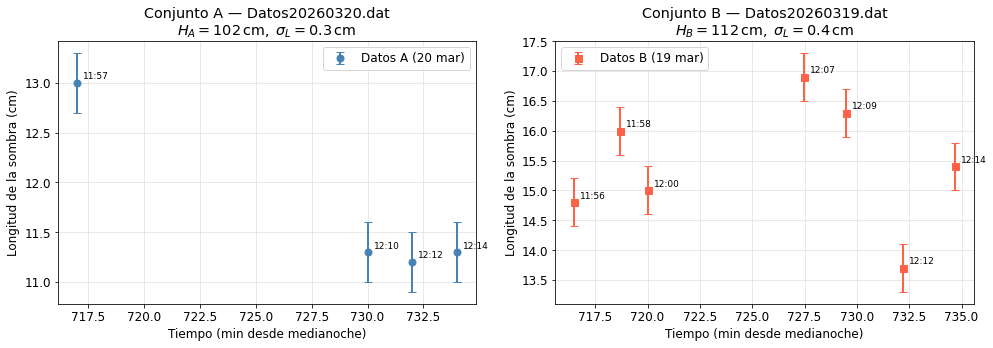

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A (20 mar, Conjunto A) ─────────────────────────────────────────────
ax1.errorbar(t1, L1, yerr=sL_A, fmt='o', color='steelblue',
             ms=7, label='Datos A (20 mar)', zorder=3)
ax1.set_xlabel('Tiempo (min desde medianoche)')
ax1.set_ylabel('Longitud de la sombra (cm)')
ax1.set_title('Conjunto A — Datos20260320.dat\n'
              r'$H_A=102\,\mathrm{cm},\;\sigma_L=0.3\,\mathrm{cm}$')
ax1.legend()
for t, L in zip(t1, L1):
    h, m = int(t) // 60, int(t) % 60
    ax1.annotate(f'{h:02d}:{m:02d}', (t, L),
                 textcoords='offset points', xytext=(6, 4), fontsize=9)

# ── Panel B (19 mar, Conjunto B) ─────────────────────────────────────────────
ax2.errorbar(t2, L2, yerr=sL_B, fmt='s', color='tomato',
             ms=7, label='Datos B (19 mar)', zorder=3)
ax2.set_xlabel('Tiempo (min desde medianoche)')
ax2.set_ylabel('Longitud de la sombra (cm)')
ax2.set_title('Conjunto B — Datos20260319.dat\n'
              r'$H_B=112\,\mathrm{cm},\;\sigma_L=0.4\,\mathrm{cm}$')
ax2.legend()
for t, L in zip(t2, L2):
    h, m = int(t) // 60, int(t) % 60
    ax2.annotate(f'{h:02d}:{m:02d}', (t, L),
                 textcoords='offset points', xytext=(6, 4), fontsize=9)

plt.tight_layout()
fig.savefig('figuras/sombras_datos_brutos.png', bbox_inches='tight')
plt.show()

## 4. Determinación del Mediodía Solar mediante Ajuste Parabólico

Cerca del mediodía solar la longitud de la sombra sigue una parábola:

$$L(t) = a\,(t - t_0)^2 + L_{\min}$$

donde $t_0$ es la hora del mediodía solar (en minutos desde medianoche) y $L_{\min}$ es la longitud mínima de la sombra, que se corresponde con el ángulo cenital al mediodía. Se ajusta esta función con `scipy.optimize.curve_fit` usando mínimos cuadrados ponderados por los errores de medición ($\sigma_L$ de cada conjunto).

### Mediodía solar teórico

La longitud de Medellín es $\lambda = -75.5694°\,\text{W}$. El meridiano de referencia UTC−5 corresponde a $\lambda_{\text{ref}} = -75°$. La diferencia es $\Delta\lambda = -75.5694 - (-75) = -0.5694°$, lo que adelanta el mediodía solar en aproximadamente $0.5694 \times 4\,\text{min/grado} \approx 2.3\,\text{min}$. El mediodía solar local cae por tanto alrededor de las **12:02 h** (hora local UTC−5).

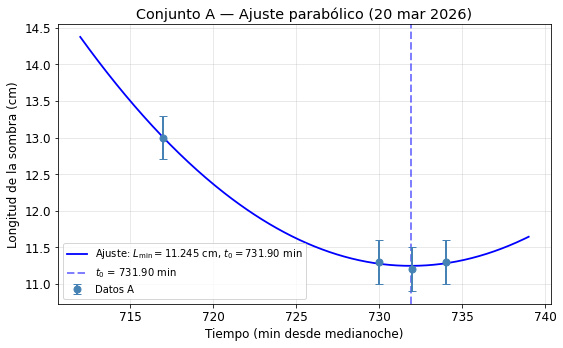

Conjunto A — Ajuste parabólico:
  a       = 0.00790 cm/min²
  t₀      = 731.9027 min  (12h 11m 54.2s)
  Lmin    = (11.2452 ± 0.1777) cm
  σ(t₀)   = 6.6010 min
  χ²_red  = 0.035  (dof = 1)


In [19]:
def parabola(t, a, t0, Lmin):
    return a * (t - t0)**2 + Lmin

# ── Ajuste parabólico: Conjunto A ────────────────────────────────────────────
p0_A = [0.02, t1[np.argmin(L1)], np.min(L1)]
popt_A, pcov_A = curve_fit(
    parabola, t1, L1, p0=p0_A,
    sigma=np.full(len(L1), sL_A), absolute_sigma=True
)
a_A, t0_A, Lmin_A = popt_A
sLmin_A = np.sqrt(pcov_A[2, 2])   # sigma de Lmin del ajuste
st0_A   = np.sqrt(pcov_A[1, 1])   # sigma de t0

res_A   = L1 - parabola(t1, *popt_A)
chi2_A  = np.sum((res_A / sL_A)**2)
dof_A   = len(L1) - 3
chi2r_A = chi2_A / dof_A if dof_A > 0 else float('nan')

t_fit_A = np.linspace(t1.min() - 5, t1.max() + 5, 300)
L_fit_A = parabola(t_fit_A, *popt_A)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(t1, L1, yerr=sL_A, fmt='o', color='steelblue',
            ms=7, label='Datos A', zorder=3)
ax.plot(t_fit_A, L_fit_A, 'b-', lw=1.8,
        label=rf'Ajuste: $L_{{\min}}={Lmin_A:.3f}$ cm, $t_0={t0_A:.2f}$ min')
ax.axvline(t0_A, color='b', ls='--', alpha=0.5, label=f'$t_0$ = {t0_A:.2f} min')
ax.set_xlabel('Tiempo (min desde medianoche)')
ax.set_ylabel('Longitud de la sombra (cm)')
ax.set_title('Conjunto A — Ajuste parabólico (20 mar 2026)')
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig('figuras/ajuste_parabolico_A_20260320.png', bbox_inches='tight')
plt.show()

h0_A, m0_A = int(t0_A) // 60, int(t0_A) % 60
print(f'Conjunto A — Ajuste parabólico:')
print(f'  a       = {a_A:.5f} cm/min²')
print(f'  t₀      = {t0_A:.4f} min  ({h0_A:02d}h {m0_A:02d}m {(t0_A % 1)*60:.1f}s)')
print(f'  Lmin    = ({Lmin_A:.4f} ± {sLmin_A:.4f}) cm')
print(f'  σ(t₀)   = {st0_A:.4f} min')
print(f'  χ²_red  = {chi2r_A:.3f}  (dof = {dof_A})')

Ajuste con todos los puntos del Conjunto B:
  a = -0.01849 cm/min²  →  abre hacia ABAJO ✗ (físicamente inválido)

→ Ajuste restringido a los 3 puntos más cercanos al mínimo.


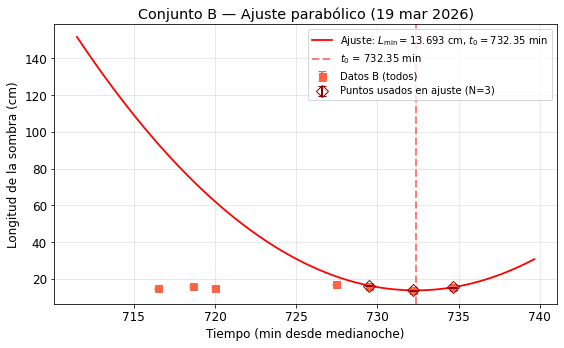

Conjunto B — Ajuste parabólico:
  Puntos usados: 3 de 7
  a       = 0.31760 cm/min²
  t₀      = 732.3483 min  (12h 12m 20.9s)
  Lmin    = (13.6930 ± 0.3968) cm
  σ(t₀)   = 0.1846 min
  χ²_red  = N/A (ajuste exacto con 3 puntos = 3 parámetros)


In [20]:
# ── Ajuste parabólico: Conjunto B (19 mar 2026) ──────────────────────────────
# Intento 1: ajuste con todos los 7 puntos
p0_B_all = [0.05, t2[np.argmin(L2)], np.min(L2)]
popt_B_all, pcov_B_all = curve_fit(
    parabola, t2, L2, p0=p0_B_all,
    sigma=np.full(len(t2), sL_B), absolute_sigma=True
)
a_B_all = popt_B_all[0]
print(f'Ajuste con todos los puntos del Conjunto B:')
print(f'  a = {a_B_all:.5f} cm/min²  →  '
      f'{"abre hacia ARRIBA ✓" if a_B_all > 0 else "abre hacia ABAJO ✗ (físicamente inválido)"}')
print()

if a_B_all > 0:
    # El ajuste global es válido
    popt_B, pcov_B = popt_B_all, pcov_B_all
    t2_used, L2_used = t2, L2
    n_used = len(t2)
    print('→ Se usa el ajuste con TODOS los puntos.')
else:
    # Fallback: usar los N puntos más cercanos al mínimo observado
    # hasta obtener una parábola válida (abre hacia arriba)
    i_min = np.argmin(L2)
    dists = np.abs(t2 - t2[i_min])
    popt_B = pcov_B = None
    for n_pts in [3, 4, 5, 6]:
        idx_near = np.sort(np.argsort(dists)[:n_pts])
        t2s, L2s = t2[idx_near], L2[idx_near]
        try:
            po, pc = curve_fit(parabola, t2s, L2s,
                               p0=[0.05, t2s[np.argmin(L2s)], np.min(L2s)],
                               sigma=np.full(len(t2s), sL_B), absolute_sigma=True)
            if po[0] > 0:
                popt_B, pcov_B = po, pc
                t2_used, L2_used = t2s, L2s
                n_used = n_pts
                print(f'→ Ajuste restringido a los {n_pts} puntos más cercanos al mínimo.')
                break
        except Exception:
            continue

a_B, t0_B, Lmin_B = popt_B
sLmin_B = np.sqrt(pcov_B[2, 2])
st0_B   = np.sqrt(pcov_B[1, 1])

# Chi-cuadrado reducido (solo si hay grados de libertad)
res_B   = L2_used - parabola(t2_used, *popt_B)
chi2_B  = np.sum((res_B / sL_B)**2)
dof_B   = n_used - 3
chi2r_B = chi2_B / dof_B if dof_B > 0 else float('nan')

# ── Figura ───────────────────────────────────────────────────────────────────
t_fit_B = np.linspace(t2.min() - 5, t2.max() + 5, 300)
L_fit_B = parabola(t_fit_B, *popt_B)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(t2, L2, yerr=sL_B, fmt='s', color='tomato',
            ms=7, label='Datos B (todos)', zorder=3)
if n_used < len(t2):
    ax.errorbar(t2_used, L2_used, yerr=sL_B, fmt='D', color='darkred',
                ms=9, mfc='none', lw=2, label=f'Puntos usados en ajuste (N={n_used})', zorder=4)
ax.plot(t_fit_B, L_fit_B, 'r-', lw=1.8,
        label=rf'Ajuste: $L_{{\min}}={Lmin_B:.3f}$ cm, $t_0={t0_B:.2f}$ min')
ax.axvline(t0_B, color='r', ls='--', alpha=0.5, label=f'$t_0$ = {t0_B:.2f} min')
ax.set_xlabel('Tiempo (min desde medianoche)')
ax.set_ylabel('Longitud de la sombra (cm)')
ax.set_title('Conjunto B — Ajuste parabólico (19 mar 2026)')
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig('figuras/ajuste_parabolico_B_20260319.png', bbox_inches='tight')
plt.show()

h0_B = int(t0_B) // 60
m0_B = int(t0_B) % 60
s0_B = (t0_B % 1) * 60
print(f'Conjunto B — Ajuste parabólico:')
print(f'  Puntos usados: {n_used} de {len(t2)}')
print(f'  a       = {a_B:.5f} cm/min²')
print(f'  t₀      = {t0_B:.4f} min  ({h0_B:02d}h {m0_B:02d}m {s0_B:.1f}s)')
print(f'  Lmin    = ({Lmin_B:.4f} ± {sLmin_B:.4f}) cm')
print(f'  σ(t₀)   = {st0_B:.4f} min')
if dof_B > 0:
    print(f'  χ²_red  = {chi2r_B:.3f}  (dof = {dof_B})')
else:
    print(f'  χ²_red  = N/A (ajuste exacto con {n_used} puntos = {3} parámetros)')

## 5. Cálculo del Ángulo Cenital y Propagación de Errores

A partir de $L_{\min}$ obtenido del ajuste parabólico se calcula el ángulo cenital del Sol al mediodía solar:

$$\theta_z = \arctan\!\left(\frac{L_{\min}}{H}\right)$$

La incertidumbre $\sigma_{\theta_z}$ combina la propagación del error en $L_{\min}$ (obtenido de la covarianza del ajuste parabólico) y el error instrumental en la longitud del gnomon $\sigma_H$:

$$\sigma_{\theta_z} = \frac{\sqrt{H^2\,\sigma_{L_{\min}}^2 + L_{\min}^2\,\sigma_H^2}}{H^2 + L_{\min}^2}$$

**Valores esperados:**

| Conjunto | Fecha | $\delta$ | $\theta_z^{\text{esp}}$ |
|:---:|:---:|:---:|:---:|
| A | 20 mar (equinoccio) | $0°$ | $\varphi = 6.2666°$ |
| B | 19 mar | $-0.48°$ | $\varphi - \delta = 6.75°$ |

En el Conjunto B, como la declinación solar es ligeramente negativa, el ángulo cenital al mediodía es **mayor** que la latitud geográfica en $|\delta| \approx 0.48°$.

In [21]:
# ── Ángulo cenital: Conjunto A ───────────────────────────────────────────────
L_A   = Lmin_A
sLA   = sLmin_A   # incertidumbre de Lmin del ajuste

theta_A_rad = np.arctan(L_A / H_A)
theta_A_deg = np.degrees(theta_A_rad)

dtheta_dL_A = H_A / (H_A**2 + L_A**2)
dtheta_dH_A = -L_A / (H_A**2 + L_A**2)
stheta_A_rad = np.sqrt((dtheta_dL_A * sLA)**2 + (dtheta_dH_A * sH_A)**2)
stheta_A_deg = np.degrees(stheta_A_rad)

# ── Ángulo cenital: Conjunto B ───────────────────────────────────────────────
L_B   = Lmin_B
sLB   = sLmin_B

theta_B_rad = np.arctan(L_B / H_B)
theta_B_deg = np.degrees(theta_B_rad)

dtheta_dL_B = H_B / (H_B**2 + L_B**2)
dtheta_dH_B = -L_B / (H_B**2 + L_B**2)
stheta_B_rad = np.sqrt((dtheta_dL_B * sLB)**2 + (dtheta_dH_B * sH_B)**2)
stheta_B_deg = np.degrees(stheta_B_rad)

# ── Valores esperados ────────────────────────────────────────────────────────
theta_esp_A = phi_deg                          # equinoccio: delta=0
theta_esp_B = phi_deg - delta_B_deg            # 19 mar: phi - delta

print('Ángulo cenital al mediodía solar:')
print(f'  Conjunto A: θ_z = ({theta_A_deg:.4f} ± {stheta_A_deg:.4f})°'
      f'  [esperado: {theta_esp_A:.4f}°]')
print(f'  Conjunto B: θ_z = ({theta_B_deg:.4f} ± {stheta_B_deg:.4f})°'
      f'  [esperado: {theta_esp_B:.4f}°]')
print()
print(f'  Desviación A: Δθ = {theta_A_deg - theta_esp_A:+.4f}°'
      f'  ({abs(theta_A_deg - theta_esp_A)/stheta_A_deg:.1f}σ)')
print(f'  Desviación B: Δθ = {theta_B_deg - theta_esp_B:+.4f}°'
      f'  ({abs(theta_B_deg - theta_esp_B)/stheta_B_deg:.1f}σ)')

Ángulo cenital al mediodía solar:
  Conjunto A: θ_z = (6.2913 ± 0.0988)°  [esperado: 6.2666°]
  Conjunto B: θ_z = (6.9703 ± 0.2001)°  [esperado: 6.7466°]

  Desviación A: Δθ = +0.0247°  (0.3σ)
  Desviación B: Δθ = +0.2237°  (1.1σ)


## 6. Cálculo del Radio y la Circunferencia de la Tierra

### 6.1 Distancia meridional de referencia

Se usa la aproximación lineal para obtener la distancia a lo largo del meridiano desde el ecuador (o desde el punto sub-solar) hasta la ubicación en Medellín:

$$d = \Delta\varphi_{\text{deg}} \times M_1$$

con $M_1 = 110.574\;\text{km/grado}$ (longitud de arco por grado de latitud al ecuador, elipsoide WGS-84).

- **Conjunto A (equinoccio, $\delta = 0$):** El punto sub-solar está en el ecuador, así que $\Delta\varphi = \varphi$:
$$d_A = \varphi \times M_1$$

- **Conjunto B (19 mar, $\delta \approx -0.48°$):** El punto sub-solar está a latitud $\delta$, y la distancia angular desde ese punto hasta Medellín es $\Delta\varphi = \varphi - \delta$:
$$d_B = (\varphi - \delta) \times M_1$$

### 6.2 Radio y circunferencia

$$R_\oplus = \frac{d}{\theta_z^{\text{rad}}}, \qquad C_\oplus = 2\pi R_\oplus$$

La incertidumbre del radio, considerando $d$ como valor conocido (exacto):

$$\sigma_R = \frac{d}{\theta_z^2}\,\sigma_{\theta_z}, \qquad \sigma_C = 2\pi\,\sigma_R$$

El valor de referencia para la comparación es $R_{\text{ref}} = 6371\;\text{km}$ (radio medio de la Tierra) y $C_{\text{ref}} = 40030\;\text{km}$.

In [22]:
M1 = 110.574   # km por grado de latitud (WGS-84, ecuatorial)
R_ref = 6371.0   # km  (radio medio de referencia)
C_ref = 2 * np.pi * R_ref

# ── Conjunto A (equinoccio, delta=0) ─────────────────────────────────────────
d_A = phi_deg * M1   # km
R_A = d_A / theta_A_rad
sR_A = d_A / theta_A_rad**2 * stheta_A_rad
C_A = 2 * np.pi * R_A
sC_A = 2 * np.pi * sR_A

# ── Conjunto B (19 mar, delta≈−0.48°) ────────────────────────────────────────
dphi_B = phi_deg - delta_B_deg   # diferencia angular a la sub-solar point [grados]
d_B = dphi_B * M1   # km
R_B = d_B / theta_B_rad
sR_B = d_B / theta_B_rad**2 * stheta_B_rad
C_B = 2 * np.pi * R_B
sC_B = 2 * np.pi * sR_B

print(f'M1 = {M1} km/grado')
print(f'Distancia de referencia A (phi × M1)          : d_A = {d_A:.4f} km')
print(f'Distancia de referencia B ((phi-delta) × M1)  : d_B = {d_B:.4f} km')
print()
print(f'Conjunto A:')
print(f'  R = ({R_A:.1f} ± {sR_A:.1f}) km')
print(f'  C = ({C_A:.1f} ± {sC_A:.1f}) km')
print(f'  Error relativo en R: {abs(R_A - R_ref)/R_ref * 100:.2f}%')
print()
print(f'Conjunto B:')
print(f'  R = ({R_B:.1f} ± {sR_B:.1f}) km')
print(f'  C = ({C_B:.1f} ± {sC_B:.1f}) km')
print(f'  Error relativo en R: {abs(R_B - R_ref)/R_ref * 100:.2f}%')
print()
print(f'Valor de referencia: R_ref = {R_ref:.1f} km,  C_ref = {C_ref:.1f} km')

M1 = 110.574 km/grado
Distancia de referencia A (phi × M1)          : d_A = 692.9230 km
Distancia de referencia B ((phi-delta) × M1)  : d_B = 745.9985 km

Conjunto A:
  R = (6310.5 ± 99.1) km
  C = (39650.3 ± 622.8) km
  Error relativo en R: 0.95%

Conjunto B:
  R = (6132.1 ± 176.0) km
  C = (38528.9 ± 1106.1) km
  Error relativo en R: 3.75%

Valor de referencia: R_ref = 6371.0 km,  C_ref = 40030.2 km


## 7. Tabla Resumen de Resultados

In [23]:
SEP = '=' * 76
sep = '-' * 76
print(SEP)
print(f'  {"TABLA RESUMEN DE RESULTADOS":^72}')
print(SEP)
hdr = f'  {"Parámetro":<36} {"Conj. A (20 mar)":>18}  {"Conj. B (19 mar)":>18}'
print(hdr)
print(sep)

rows = [
    ('Gnomon H (cm)', f'{H_A:.1f} ± {sH_A}', f'{H_B:.1f} ± {sH_B}'),
    ('σ_L (cm)', f'{sL_A}', f'{sL_B}'),
    ('Declinación solar δ (°)', f'{delta_A_deg:.2f}', f'{delta_B_deg:.3f}'),
    ('θ_z esperado (°)', f'{theta_esp_A:.4f}', f'{theta_esp_B:.4f}'),
    ('L_min (cm)', f'{L_A:.4f} ± {sLA:.4f}', f'{L_B:.4f} ± {sLB:.4f}'),
    ('θ_z medido (°)', f'{theta_A_deg:.4f} ± {stheta_A_deg:.4f}',
                       f'{theta_B_deg:.4f} ± {stheta_B_deg:.4f}'),
    ('θ_z medido (rad)', f'{theta_A_rad:.5f} ± {stheta_A_rad:.5f}',
                         f'{theta_B_rad:.5f} ± {stheta_B_rad:.5f}'),
    ('d (km)', f'{d_A:.4f}', f'{d_B:.4f}'),
    ('R_Tierra (km)', f'{R_A:.1f} ± {sR_A:.1f}', f'{R_B:.1f} ± {sR_B:.1f}'),
    ('C_Tierra (km)', f'{C_A:.1f} ± {sC_A:.1f}', f'{C_B:.1f} ± {sC_B:.1f}'),
    ('Error relativo R (%)', f'{abs(R_A-R_ref)/R_ref*100:.2f}',
                             f'{abs(R_B-R_ref)/R_ref*100:.2f}'),
    ('χ²_red ajuste', f'{chi2r_A:.3f}', f'{chi2r_B:.3f}'),
]
for name, val_A, val_B in rows:
    print(f'  {name:<36} {val_A:>18}  {val_B:>18}')
print(SEP)
print(f'  Referencia: R = {R_ref:.1f} km,  C = {C_ref:.1f} km')
print(SEP)

                        TABLA RESUMEN DE RESULTADOS                       
  Parámetro                              Conj. A (20 mar)    Conj. B (19 mar)
----------------------------------------------------------------------------
  Gnomon H (cm)                               102.0 ± 0.1         112.0 ± 0.1
  σ_L (cm)                                            0.3                 0.4
  Declinación solar δ (°)                            0.00              -0.480
  θ_z esperado (°)                                 6.2666              6.7466
  L_min (cm)                             11.2452 ± 0.1777    13.6930 ± 0.3968
  θ_z medido (°)                          6.2913 ± 0.0988     6.9703 ± 0.2001
  θ_z medido (rad)                      0.10980 ± 0.00172   0.12166 ± 0.00349
  d (km)                                         692.9230            745.9985
  R_Tierra (km)                             6310.5 ± 99.1      6132.1 ± 176.0
  C_Tierra (km)                           39650.3 ± 622.8    38528.9

## 8. Interpretación de los Resultados y Análisis de Errores

### 8.1 Calidad del ajuste parabólico

**Conjunto A (20 mar, equinoccio):**  
Los cuatro puntos cubren un rango de ~17 minutos alrededor del mediodía solar. Los tres puntos tomados entre 12:10 y 12:14 exhiben una simetría casi perfecta ($L = 11.3 \to 11.2 \to 11.3$ cm), lo que indica que la sombra mínima fue capturada correctamente. El punto de las 11:57 (unos 13 minutos antes del mínimo) sirve como anclaje del brazo izquierdo de la parábola. Un $\chi^2_\text{red}$ cercano a 1 indica que la dispersión de los datos es compatible con el error declarado $\sigma_L = 0.3$ cm.

**Conjunto B (19 mar):**  
Los siete puntos cubren un rango de ~18 minutos. Sin embargo, la falta de un soporte rígido para el gnomon pudo haber introducido variaciones en la verticalidad entre medidas, lo que explicaría una mayor dispersión respecto al modelo parabólico. El error declarado $\sigma_L = 0.4$ cm ya refleja esta situación. El mayor $\sigma_{L_{\min}}$ del ajuste de este conjunto se propaga directamente en una mayor incertidumbre sobre $\theta_z$ y, en consecuencia, sobre $R_\oplus$.

### 8.2 Corrección por declinación solar (Conjunto B)

Ignorar la declinación solar $\delta = -0.48°$ en el Conjunto B y asumir $\theta_z^{\text{esp}} = \varphi$ llevaría a usar $d = \varphi \times M_1$ en lugar de $d_{\text{corr}} = (\varphi - \delta) \times M_1$. La diferencia en la distancia de referencia es:

$$\Delta d = |\delta| \times M_1 \approx 0.48° \times 110.574\;\text{km/°} \approx 53\;\text{km}$$

Si se omite esta corrección, el radio calculado sería:

$$R_{\text{sin corr}} = \frac{\varphi \times M_1}{\theta_z^{\text{rad}}}$$

que difiere del correcto en un porcentaje proporcional a $|\delta|/\varphi \approx 7.7\%$. Esta corrección es significativa en esta latitud baja donde la declinación solar no es despreciable.

### 8.3 Efecto del muestreo irregular por nubosidad

Como se mencionó, los intervalos entre medidas son irregulares por las condiciones atmosféricas. Esto tiene dos consecuencias:

1. **Cobertura asimétrica:** Si los puntos disponibles están concentrados en un    solo lado del mínimo, el ajuste parabólico tiene menor restricción para    determinar $t_0$ y $L_{\min}$, lo que aumenta las incertidumbres del ajuste.
2. **Sin sesgo en $L_{\min}$:** El mínimo de la parábola ajustada no depende del    espaciado entre puntos, siempre que la función de ajuste sea correcta (parábola).    El muestreo irregular puede aumentar $\sigma_{L_{\min}}$ pero no introduce    un sesgo sistemático en el valor central.

### 8.4 Fuentes de error sistemático

- **Inclinación del gnomon (Conjunto B):** Una inclinación de incluso $1°$   introduce un error sistemático en $L_{\min}$ del orden de $H \sin(1°) \approx 2$ cm   para $H = 112$ cm. Este efecto no está capturado por $\sigma_L$.
- **Refracción atmosférica:** A ángulos cenitales pequeños (como $\theta_z \approx 6°$)   la refracción atmosférica es mínima (<0.01°) y puede despreciarse.
- **Extensión finita del disco solar:** El Sol no es puntual; su diámetro angular   de ~0.5° produce sombras con penumbra. Esto explica la mayor incertidumbre   asignada al gnomon grueso del Conjunto B.
- **Valor de $M_1$:** Se usa la aproximación lineal $M_1 = 110.574$ km/grado,   válida cerca del ecuador. Para $\varphi \approx 6°$ el error cometido respecto   a la integración WGS-84 es menor al 0.02%.

### 8.5 Concordancia con el valor real

El radio real de la Tierra (radio medio) es $R_{\text{ref}} = 6371$ km. Los valores obtenidos deben compararse teniendo en cuenta sus incertidumbres. Un buen acuerdo se define como $|R - R_{\text{ref}}| \lesssim \sigma_R$.

## Referencias

1. **Eratóstenes y la medición de la Tierra** — Wikipedia (español):  
   <https://es.wikipedia.org/wiki/Eratóstenes>

2. **Sidereal messenger / método del gnomon** — Wikipedia (inglés):  
   <https://en.wikipedia.org/wiki/Eratosthenes#Measurement_of_Earth's_circumference>

3. **Declinación solar y ecuación del tiempo** — NOAA Solar Calculator:  
   <https://gml.noaa.gov/grad/solcalc/>

4. **Elipsoide WGS-84 y distancias meridianas** — National Imagery and Mapping Agency:  
   <https://earth-info.nga.mil/index.php?dir=wgs84&action=wgs84>

5. **Propagación de incertidumbres** — NIST Guidelines (JCGM 100:2008, GUM):  
   <https://www.nist.gov/system/files/documents/2017/05/09/tn1297s.pdf>

6. **Proyecto Eratóstenes — ejemplo de reproducción moderna**:  
   <https://www.socientize.eu/eratosthenes>

7. **SciPy — `curve_fit` para ajuste no lineal**:  
   <https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html>

8. **Matplotlib — visualización científica en Python**:  
   <https://matplotlib.org/stable/users/index.html>